[download this notebook here](https://github.com/HumanCompatibleAI/imitation/blob/master/docs/tutorials/1_train_bc.ipynb)
# Train an Agent using Behavior Cloning

Behavior cloning is the most naive approach to imitation learning. 
We take the transitions of trajectories taken by some expert and use them as training samples to train a new policy.
The method has many drawbacks and often does not work. 
However in this example, where we use an agent for the seals/CartPole-v0 environment, it is feasible.

Note that we use a variant of the CartPole environment from the seals package, which has fixed episode durations. Read more about why we do this [here](https://imitation.readthedocs.io/en/latest/main-concepts/variable_horizon.html).

First we need some kind of expert in CartPole so we can sample some expert trajectories.
For convenience we just download one from the HuggingFace model hub.

If you want to train an expert yourself have a look at the [training documenation](https://rl-baselines3-zoo.readthedocs.io/en/master/guide/train.html#basic-usage) of RL Baselines3 Zoo.

In [1]:
import numpy as np
import gymnasium as gym
from imitation.policies.serialize import load_policy
from imitation.util.util import make_vec_env
from imitation.data.wrappers import RolloutInfoWrapper
from matplotlib import pyplot as plt

env = make_vec_env(
    "seals:seals/CartPole-v0",
    rng=np.random.default_rng(),
    post_wrappers=[
        lambda env, _: RolloutInfoWrapper(env)
    ],  # needed for computing rollouts later
)
expert = load_policy(
    "ppo-huggingface",
    organization="HumanCompatibleAI",
    env_name="seals/CartPole-v0",
    venv=env,
)

/home/matthew/projects/test_imitation/.venv/lib/python3.13/site-packages/stable_baselines3/common/save_util.py:166: UserWarning: Could not deserialize object learning_rate. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(
/home/matthew/projects/test_imitation/.venv/lib/python3.13/site-packages/stable_baselines3/common/save_util.py:166: UserWarning: Could not deserialize object clip_range. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(
/home/matthew/projects/test_imitation/.venv/lib/python3.13/site-packages/stable_baselines3/common/save_util.py:166: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(


Let's quickly check if the expert is any good.
We usually should be able to reach a reward of 500, which is the maximum achievable value.

In [2]:
from stable_baselines3.common.evaluation import evaluate_policy

reward, _ = evaluate_policy(expert, env, 10)
print(reward)

500.0


Now we can use the expert to sample some trajectories.
We flatten them right away since we are only interested in the individual transitions for behavior cloning.
`imitation` comes with a number of helper functions that makes collecting those transitions really easy. First we collect 50 episode rollouts, then we flatten them to just the transitions that we need for training.

Note that the rollout function requires a vectorized environment and needs the `RolloutInfoWrapper` around each of the environments. This is why we passed the `post_wrappers` argument to `make_vec_env` above.

In [3]:
from imitation.data import rollout

rng = np.random.default_rng()
rollouts = rollout.rollout(
    expert,
    env,
    rollout.make_sample_until(min_timesteps=None, min_episodes=50),
    rng=rng,
)
transitions = rollout.flatten_trajectories(rollouts)

Let's have a quick look at what we just generated using those library functions:

In [4]:
print(
    f"""The `rollout` function generated a list of {len(rollouts)} {type(rollouts[0])}.
After flattening, this list is turned into a {type(transitions)} object containing {len(transitions)} transitions.
The transitions object contains arrays for: {', '.join(transitions.__dict__.keys())}."
"""
)

The `rollout` function generated a list of 56 <class 'imitation.data.types.TrajectoryWithRew'>.
After flattening, this list is turned into a <class 'imitation.data.types.Transitions'> object containing 28000 transitions.
The transitions object contains arrays for: obs, acts, infos, next_obs, dones."



In [5]:
transitions[0]

{'obs': array([ 0.02048647,  0.04428037,  0.01656574, -0.03666043], dtype=float32),
 'acts': np.int64(1),
 'infos': {},
 'next_obs': array([ 0.02137208,  0.2391609 ,  0.01583253, -0.324071  ], dtype=float32),
 'dones': np.False_}

In [6]:
rollouts[0].obs.shape

(501, 4)

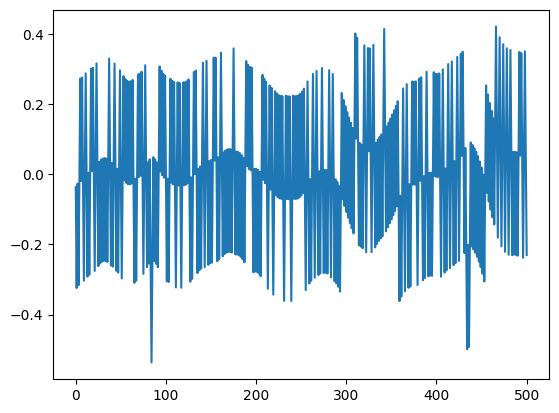

In [7]:
obs0 = rollouts[0].obs
plt.plot(obs0[:,3])

After we collected our transitions, it's time to set up our behavior cloning algorithm.

In [8]:
from imitation.algorithms import bc

bc_trainer = bc.BC(
    observation_space=env.observation_space,
    action_space=env.action_space,
    demonstrations=transitions,
    rng=rng,
)

As you can see the untrained policy only gets poor rewards:

In [9]:
reward_before_training, _ = evaluate_policy(bc_trainer.policy, env, 10)
print(f"Reward before training: {reward_before_training}")

Reward before training: 89.7


After training, we can match the rewards of the expert (500):

In [10]:
bc_trainer.train(n_epochs=1)
reward_after_training, _ = evaluate_policy(bc_trainer.policy, env, 10)
print(f"Reward after training: {reward_after_training}")

0batch [00:00, ?batch/s]

---------------------------------
| batch_size        | 32        |
| bc/               |           |
|    batch          | 0         |
|    ent_loss       | -0.000693 |
|    entropy        | 0.693     |
|    epoch          | 0         |
|    l2_loss        | 0         |
|    l2_norm        | 72.5      |
|    loss           | 0.692     |
|    neglogp        | 0.693     |
|    prob_true_act  | 0.5       |
|    samples_so_far | 32        |
---------------------------------


477batch [00:01, 343.18batch/s]

---------------------------------
| batch_size        | 32        |
| bc/               |           |
|    batch          | 500       |
|    ent_loss       | -0.000267 |
|    entropy        | 0.267     |
|    epoch          | 0         |
|    l2_loss        | 0         |
|    l2_norm        | 94.1      |
|    loss           | 0.443     |
|    neglogp        | 0.443     |
|    prob_true_act  | 0.801     |
|    samples_so_far | 16032     |
---------------------------------


856batch [00:02, 378.19batch/s]
875batch [00:02, 349.14batch/s]


Reward after training: 500.0
